In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
device = torch.device(
                    "cuda"
                    if torch.cuda.is_available()
                    else "mps" if torch.backends.mps.is_available() else "cpu"
                )
print(f"Using {device}")

# load & preprocess
data = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data['x'].T)
labs  = pd.DataFrame(data['y'].T, columns=['y'])
df = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)


Using mps


In [3]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="raw")

# # Function to Shifting Time
# def manipulate(data, sampling_rate=48000, shift_max=0.1, shift_direction = "both"):
#     shift = np.random.randint(sampling_rate * shift_max)
#     if shift_direction == 'right':
#         shift = -shift
#     elif shift_direction == 'both':
#         direction = np.random.randint(0, 2)
#         if direction == 1:
#             shift = -shift
#     augmented_data = np.roll(data, shift)
#     # Set to silence for heading/ tailing
#     if shift > 0:
#         augmented_data[:shift] = 0
#     else:
#         augmented_data[shift:] = 0
#     return augmented_data

# def manipulate(data, noise_factor=0.1):
#     noise = np.random.randn(len(data))
#     augmented_data = data + noise_factor * noise
#     # Cast back to same data type
#     augmented_data = augmented_data.astype(type(data[0]))
#     return augmented_data

# import librosa
# def manipulate(data, sampling_rate=48000, pitch_factor=0.1):
#     return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# # Randomly select 10% of row indices
# num_rows = data.get_samples().shape[0]
# frac = 0.1
# selected_idx = np.random.choice(num_rows, size=int(num_rows * frac), replace=False)

# # Apply the function in-place to selected rows
# data.X_reduced[selected_idx] = np.array([manipulate(data.X_reduced[i]) for i in selected_idx])


print(data.get_samples().shape, data.get_labels().shape)

(3309, 36000) (3309,)


[INFO] EPOCH: 1/50
Train loss: 0.641899, Train accuracy: 0.6628
Val loss: 0.802957, Val accuracy: 0.6600

[INFO] EPOCH: 2/50
Train loss: 0.575279, Train accuracy: 0.6631
Val loss: 0.641425, Val accuracy: 0.6600

[INFO] EPOCH: 3/50
Train loss: 0.492642, Train accuracy: 0.7555
Val loss: 0.586172, Val accuracy: 0.7900

[INFO] EPOCH: 4/50
Train loss: 0.419707, Train accuracy: 0.8200
Val loss: 0.507974, Val accuracy: 0.8600

[INFO] EPOCH: 5/50
Train loss: 0.332579, Train accuracy: 0.8562
Val loss: 0.334358, Val accuracy: 0.8800

[INFO] EPOCH: 6/50
Train loss: 0.267845, Train accuracy: 0.8852
Val loss: 0.307079, Val accuracy: 0.9200

[INFO] EPOCH: 7/50
Train loss: 0.248695, Train accuracy: 0.9007
Val loss: 0.277494, Val accuracy: 0.9100

[INFO] EPOCH: 8/50
Train loss: 0.203663, Train accuracy: 0.9162
Val loss: 0.311452, Val accuracy: 0.9200

[INFO] EPOCH: 9/50
Train loss: 0.189792, Train accuracy: 0.9197
Val loss: 0.211731, Val accuracy: 0.9300

[INFO] EPOCH: 10/50
Train loss: 0.173128, Trai

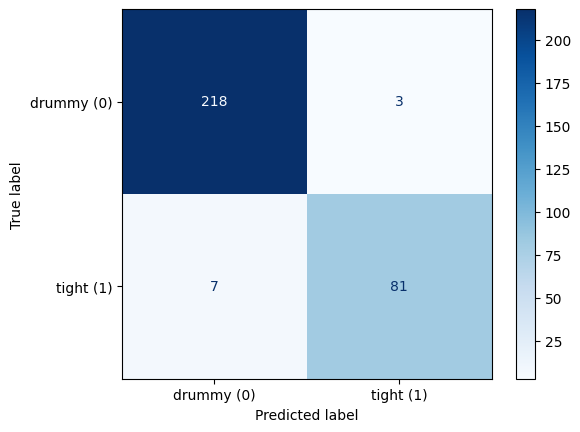


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.97      0.99      0.98       221
   tight (1)       0.96      0.92      0.94        88

    accuracy                           0.97       309
   macro avg       0.97      0.95      0.96       309
weighted avg       0.97      0.97      0.97       309



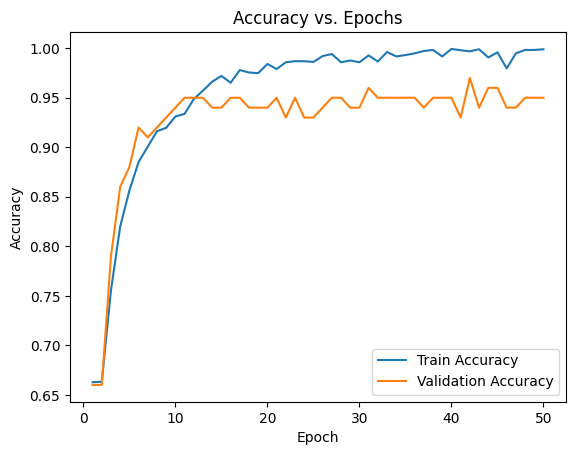

In [6]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 2900))
val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 50

history = loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=True, val_loader = val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

[INFO] EPOCH: 1/20
Train loss: 0.630172, Train accuracy: 0.6610
[INFO] EPOCH: 2/20
Train loss: 0.538513, Train accuracy: 0.6923
[INFO] EPOCH: 3/20
Train loss: 0.449885, Train accuracy: 0.7943
[INFO] EPOCH: 4/20
Train loss: 0.381304, Train accuracy: 0.8317
[INFO] EPOCH: 5/20
Train loss: 0.353066, Train accuracy: 0.8490
[INFO] EPOCH: 6/20
Train loss: 0.305309, Train accuracy: 0.8733
[INFO] EPOCH: 7/20
Train loss: 0.284579, Train accuracy: 0.8880
[INFO] EPOCH: 8/20
Train loss: 0.244030, Train accuracy: 0.9067
[INFO] EPOCH: 9/20
Train loss: 0.230389, Train accuracy: 0.9140
[INFO] EPOCH: 10/20
Train loss: 0.199022, Train accuracy: 0.9257
[INFO] EPOCH: 11/20
Train loss: 0.177115, Train accuracy: 0.9323
[INFO] EPOCH: 12/20
Train loss: 0.180785, Train accuracy: 0.9407
[INFO] EPOCH: 13/20
Train loss: 0.153052, Train accuracy: 0.9490
[INFO] EPOCH: 14/20
Train loss: 0.129869, Train accuracy: 0.9550
[INFO] EPOCH: 15/20
Train loss: 0.116267, Train accuracy: 0.9600
[INFO] EPOCH: 16/20
Train loss: 0.

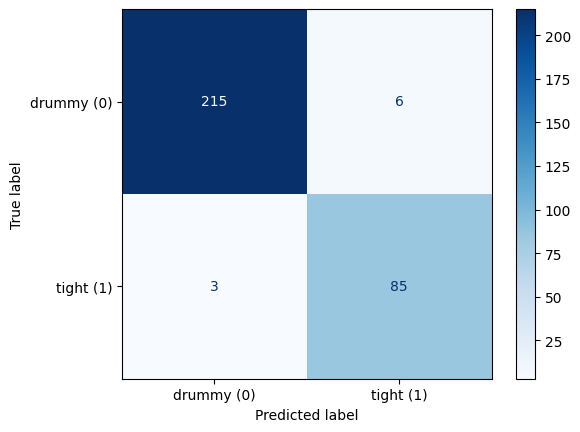


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.99      0.97      0.98       221
   tight (1)       0.93      0.97      0.95        88

    accuracy                           0.97       309
   macro avg       0.96      0.97      0.96       309
weighted avg       0.97      0.97      0.97       309



In [4]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
# val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
# val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 20

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=False,val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

# plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
# plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
# plt.title("Accuracy vs. Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()

In [2]:
# Load the data
data_2 = sio.loadmat('../data/phase2_data_20220215.mat')
samps_2 = pd.DataFrame(data_2['x'].T)
labs_2  = pd.DataFrame(data_2['y'].T, columns=['y'])

# Combine and drop any NaNs
df_2 = pd.concat([samps_2, labs_2], axis=1).dropna()

bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

df_2 = df_2.drop(index=bad_indices, errors='ignore')

shuffled_df = df_2.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]


data_2 = Extract_Features(df_X, df_Y, feature="raw")

import librosa
def manipulate(data, sampling_rate=48000, pitch_factor=0.1):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# Randomly select 10% of row indices
num_rows = data_2.get_samples().shape[0]
frac = 0.1
selected_idx = np.random.choice(num_rows, size=int(num_rows * frac), replace=False)

# Apply the function in-place to selected rows
data_2.X_reduced[selected_idx] = np.array([manipulate(data_2.X_reduced[i]) for i in selected_idx])

print(data_2.get_samples().shape, data_2.get_labels().shape)

(8229, 4800) (8229,)


[INFO] EPOCH: 1/30
Train loss: 0.677315, Train accuracy: 0.5750
[INFO] EPOCH: 2/30
Train loss: 0.632180, Train accuracy: 0.6409
[INFO] EPOCH: 3/30
Train loss: 0.601067, Train accuracy: 0.6721
[INFO] EPOCH: 4/30
Train loss: 0.576672, Train accuracy: 0.6980
[INFO] EPOCH: 5/30
Train loss: 0.546944, Train accuracy: 0.7197
[INFO] EPOCH: 6/30
Train loss: 0.522068, Train accuracy: 0.7318
[INFO] EPOCH: 7/30
Train loss: 0.506515, Train accuracy: 0.7545
[INFO] EPOCH: 8/30
Train loss: 0.496887, Train accuracy: 0.7578
[INFO] EPOCH: 9/30
Train loss: 0.486986, Train accuracy: 0.7676
[INFO] EPOCH: 10/30
Train loss: 0.473727, Train accuracy: 0.7780
[INFO] EPOCH: 11/30
Train loss: 0.466800, Train accuracy: 0.7807
[INFO] EPOCH: 12/30
Train loss: 0.453837, Train accuracy: 0.7825
[INFO] EPOCH: 13/30
Train loss: 0.446717, Train accuracy: 0.7861
[INFO] EPOCH: 14/30
Train loss: 0.444949, Train accuracy: 0.7875
[INFO] EPOCH: 15/30
Train loss: 0.432360, Train accuracy: 0.7991
[INFO] EPOCH: 16/30
Train loss: 0.

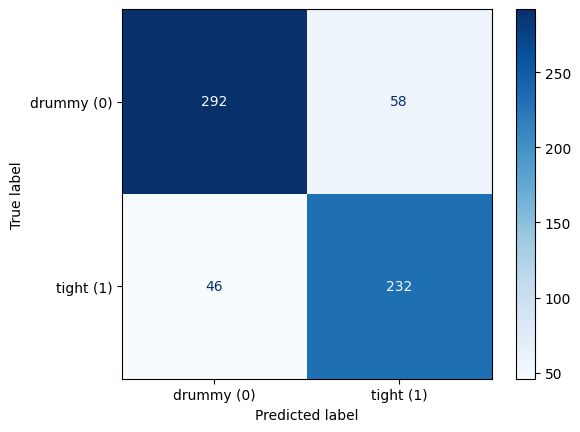


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.86      0.83      0.85       350
   tight (1)       0.80      0.83      0.82       278

    accuracy                           0.83       628
   macro avg       0.83      0.83      0.83       628
weighted avg       0.84      0.83      0.83       628



In [5]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7600))
test_idx = list(range(7600,8228))

train_data = torch.utils.data.Subset(data_2, train_idx)
test_data = torch.utils.data.Subset(data_2, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution_p2()

loops.train(model=model, model_path="./model_paths/convolution_p2.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=30)

loops.test(model_path="./model_paths/convolution_p2.pth", test_loader=test_loader, report=True)